In [1]:
!pip install seaborn

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import tensorflow as tf 
import keras 
from keras.layers  import Dense,Flatten
from  sklearn.metrics import*

In [3]:
df = pd.read_csv('Churn.csv')

In [4]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
df.shape

(10000, 14)

In [6]:
cols = list(set(df.columns))
cols

['Balance',
 'Geography',
 'HasCrCard',
 'Exited',
 'RowNumber',
 'Age',
 'EstimatedSalary',
 'CustomerId',
 'Surname',
 'Gender',
 'IsActiveMember',
 'CreditScore',
 'NumOfProducts',
 'Tenure']

In [7]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [10]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [11]:
#EDA 
#Univariate Analysis -split your features into categorcal and numerical and then univariate as well as any insight that you can find 
#Bivariate Analysis - correlation between different values 
##Feautres Engineering

In [12]:
cols

['Balance',
 'Geography',
 'HasCrCard',
 'Exited',
 'RowNumber',
 'Age',
 'EstimatedSalary',
 'CustomerId',
 'Surname',
 'Gender',
 'IsActiveMember',
 'CreditScore',
 'NumOfProducts',
 'Tenure']

In [13]:
cols.remove('CustomerId')
cols.remove('RowNumber')
cols.remove('Surname')

In [14]:
cols

['Balance',
 'Geography',
 'HasCrCard',
 'Exited',
 'Age',
 'EstimatedSalary',
 'Gender',
 'IsActiveMember',
 'CreditScore',
 'NumOfProducts',
 'Tenure']

In [15]:
cat_cols = ['NumOfProducts','IsActiveMember','HasCrCard','Gender','Geography','Tenure'
]

In [16]:
num_cols = list(set(cols)-set(cat_cols))

In [17]:
num_cols

['Balance', 'Exited', 'Age', 'EstimatedSalary', 'CreditScore']

NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64
NumOfProducts
1    50.84
2    45.90
3     2.66
4     0.60
Name: proportion, dtype: float64
Axes(0.125,0.11;0.775x0.77)


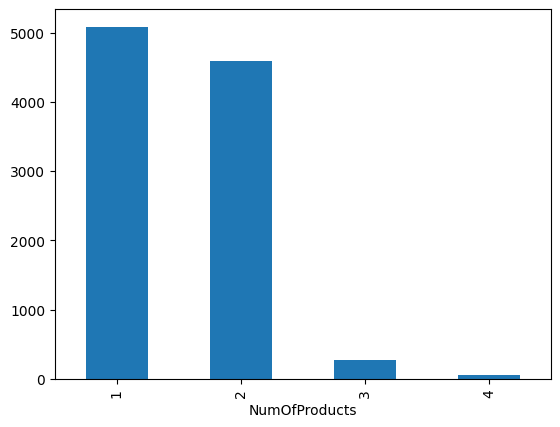

************************************************************
IsActiveMember
1    5151
0    4849
Name: count, dtype: int64
IsActiveMember
1    51.51
0    48.49
Name: proportion, dtype: float64
Axes(0.125,0.11;0.775x0.77)


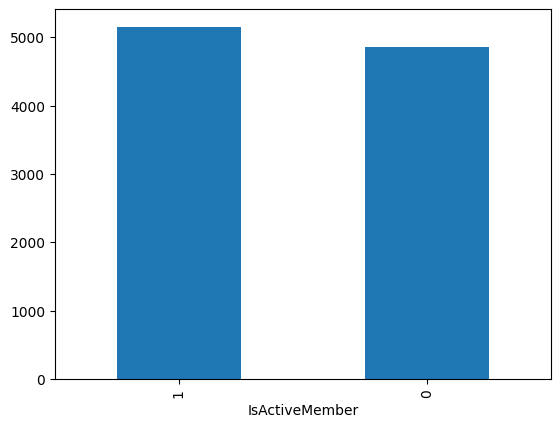

************************************************************
HasCrCard
1    7055
0    2945
Name: count, dtype: int64
HasCrCard
1    70.55
0    29.45
Name: proportion, dtype: float64
Axes(0.125,0.11;0.775x0.77)


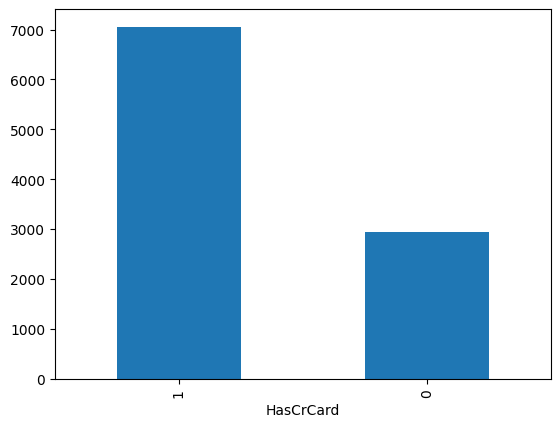

************************************************************
Gender
Male      5457
Female    4543
Name: count, dtype: int64
Gender
Male      54.57
Female    45.43
Name: proportion, dtype: float64
Axes(0.125,0.11;0.775x0.77)


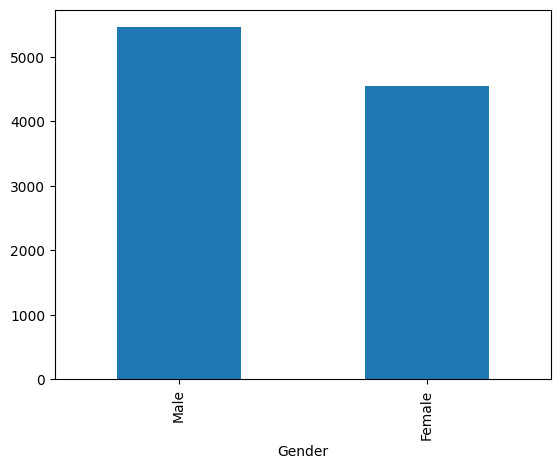

************************************************************
Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64
Geography
France     50.14
Germany    25.09
Spain      24.77
Name: proportion, dtype: float64
Axes(0.125,0.11;0.775x0.77)


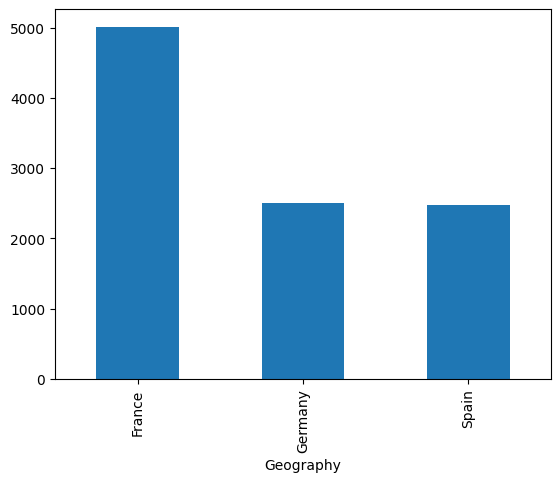

************************************************************
Tenure
2     1048
1     1035
7     1028
8     1025
5     1012
3     1009
4      989
9      984
6      967
10     490
0      413
Name: count, dtype: int64
Tenure
2     10.48
1     10.35
7     10.28
8     10.25
5     10.12
3     10.09
4      9.89
9      9.84
6      9.67
10     4.90
0      4.13
Name: proportion, dtype: float64
Axes(0.125,0.11;0.775x0.77)


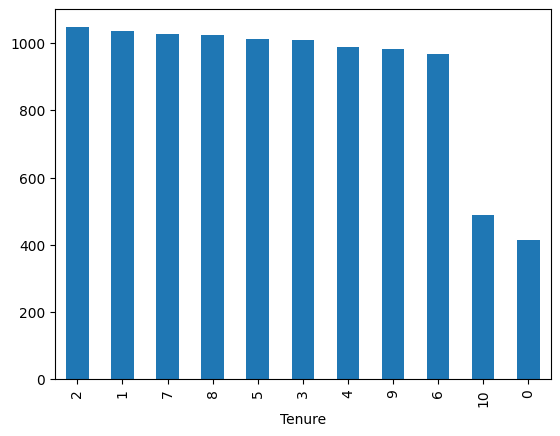

************************************************************


In [18]:
for i in cat_cols:
 print(df[i].value_counts())
 print(df[i].value_counts(normalize=True)*100)
 print(df[i].value_counts().plot.bar())
 plt.show()
 print("*"*60)

In [19]:
df.dtypes

RowNumber            int64
CustomerId           int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

Balance
Axes(0.125,0.11;0.775x0.77)


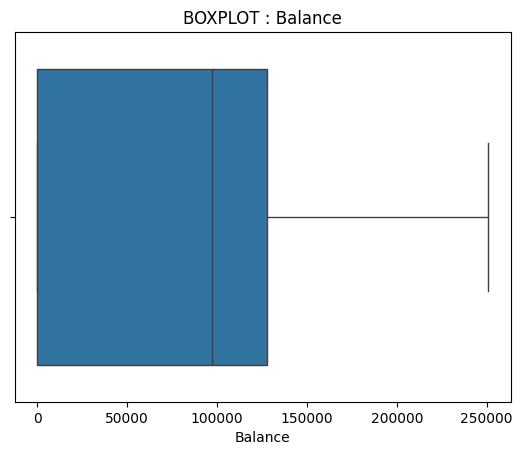

(array([3.623e+03, 6.900e+01, 3.600e+02, 1.173e+03, 2.081e+03, 1.747e+03,
       7.290e+02, 1.860e+02, 3.000e+01, 2.000e+00]), array([     0.   ,  25089.809,  50179.618,  75269.427, 100359.236,
       125449.045, 150538.854, 175628.663, 200718.472, 225808.281,
       250898.09 ]), <BarContainer object of 10 artists>)
Distribution of Balance


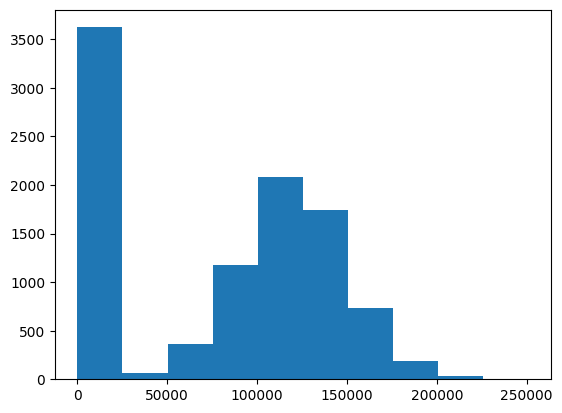

************************************************************
Exited
Axes(0.125,0.11;0.775x0.77)


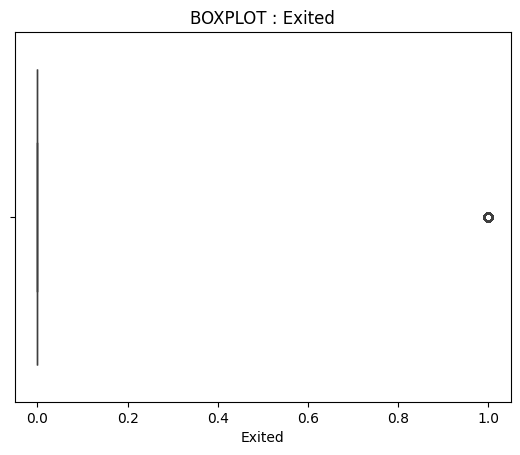

(array([7963.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
       2037.]), array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]), <BarContainer object of 10 artists>)
Distribution of Exited


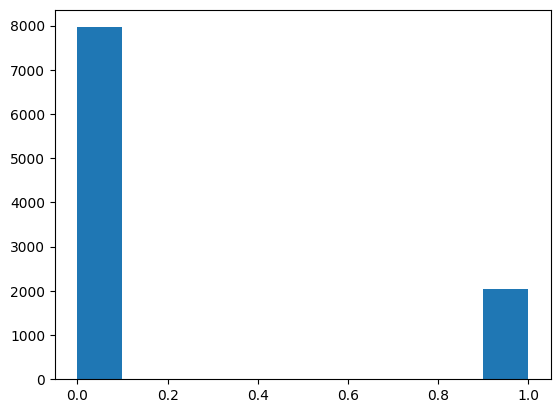

************************************************************
Age
Axes(0.125,0.11;0.775x0.77)


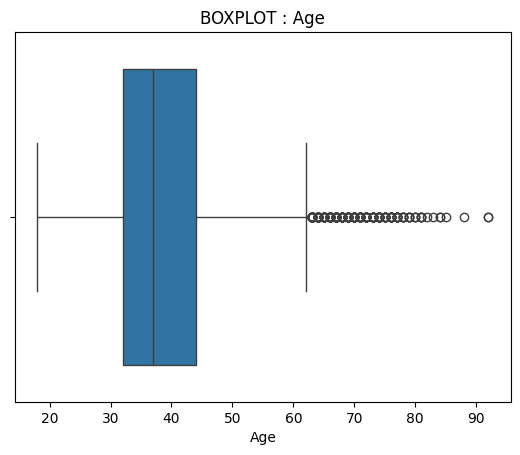

(array([ 611., 2179., 3629., 1871.,  828.,  523.,  208.,  127.,   20.,
          4.]), array([18. , 25.4, 32.8, 40.2, 47.6, 55. , 62.4, 69.8, 77.2, 84.6, 92. ]), <BarContainer object of 10 artists>)
Distribution of Age


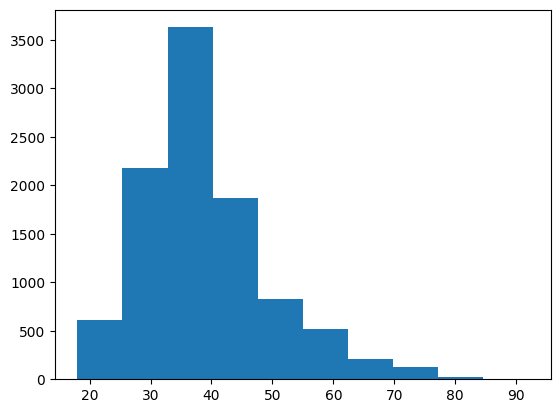

************************************************************
EstimatedSalary
Axes(0.125,0.11;0.775x0.77)


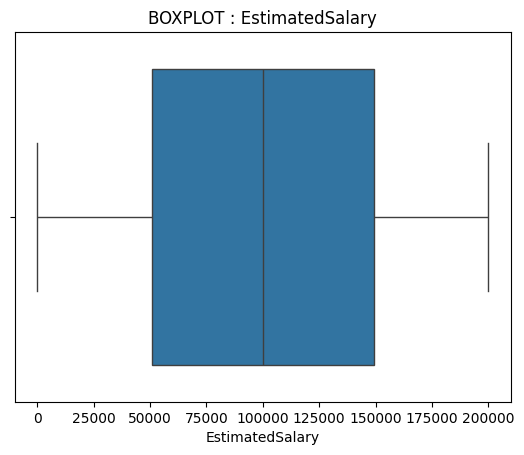

(array([ 987.,  968., 1006., 1027., 1002., 1027., 1007.,  982., 1009.,
        985.]), array([1.1580000e+01, 2.0009670e+04, 4.0007760e+04, 6.0005850e+04,
       8.0003940e+04, 1.0000203e+05, 1.2000012e+05, 1.3999821e+05,
       1.5999630e+05, 1.7999439e+05, 1.9999248e+05]), <BarContainer object of 10 artists>)
Distribution of EstimatedSalary


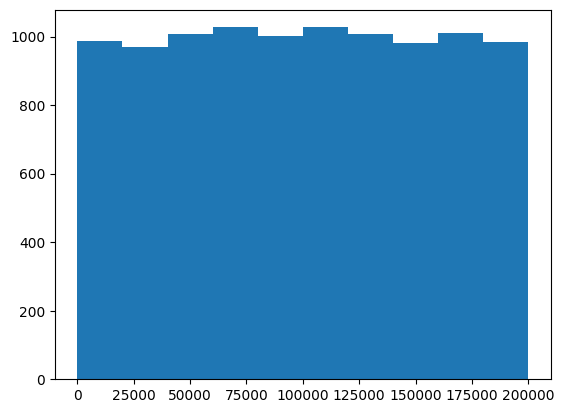

************************************************************
CreditScore
Axes(0.125,0.11;0.775x0.77)


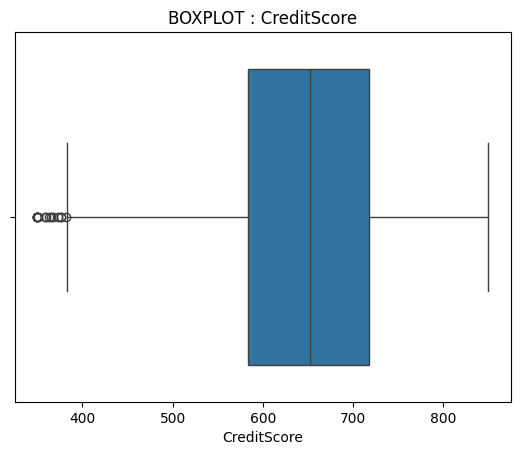

(array([  19.,  166.,  447.,  958., 1444., 1866., 1952., 1525.,  968.,
        655.]), array([350., 400., 450., 500., 550., 600., 650., 700., 750., 800., 850.]), <BarContainer object of 10 artists>)
Distribution of CreditScore


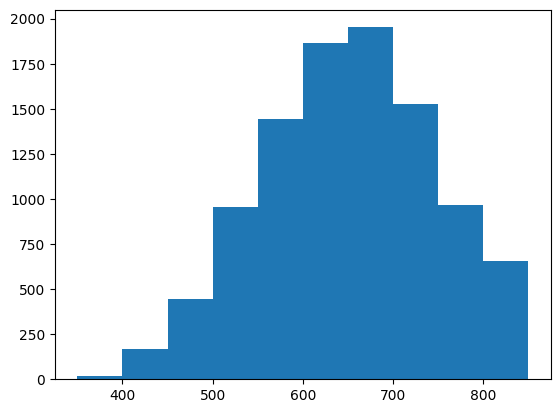

************************************************************


In [ ]:
for i in num_cols:
 print(i)
 plt.title(f"BOXPLOT : {i}")
 print(sns.boxplot(df[i],orient='h'))
 plt.show()
 print(plt.hist(df[i]))
 print(f"Distribution of {i}")
 plt.show()
 print("*"*60)

box plot of Exited with  Balance


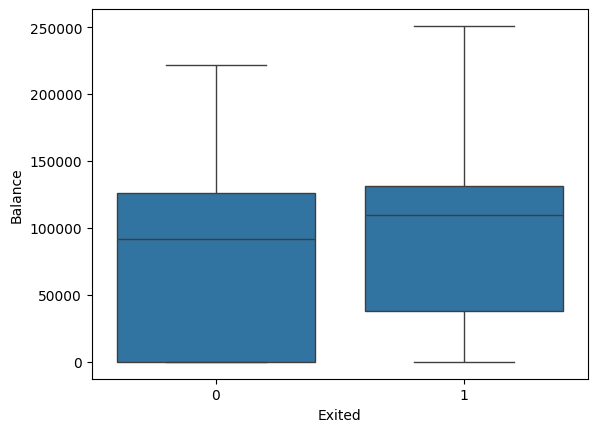

**************************************************
box plot of Exited with  Age


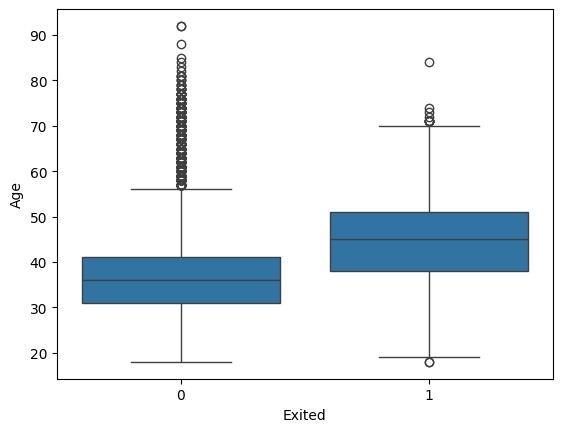

**************************************************
box plot of Exited with  EstimatedSalary


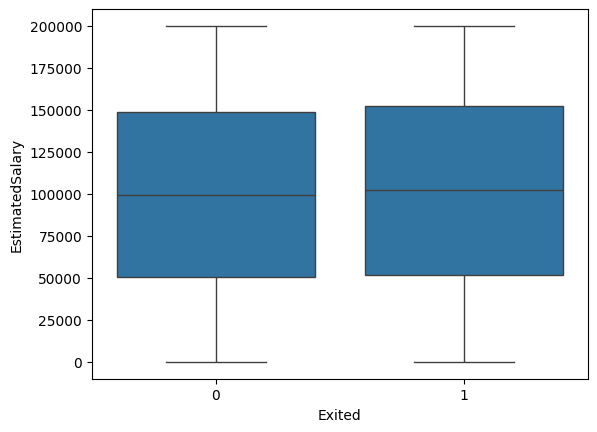

**************************************************
box plot of Exited with  CreditScore


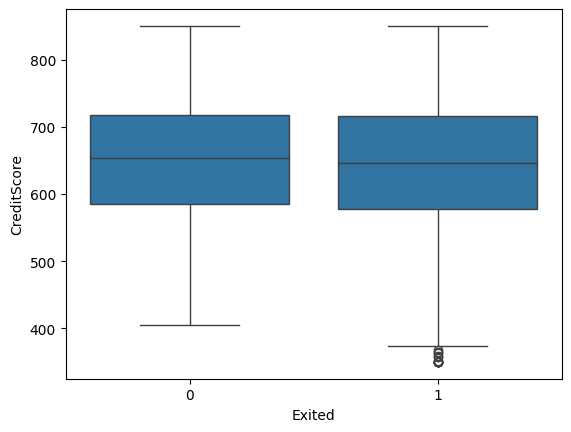

**************************************************


In [21]:
for i in num_cols:
 if i!='Exited':
  print(f"box plot of Exited with  {i}")
  sns.boxplot(x="Exited",y=i,data=df) 
  plt.show()
  print("*"*50)

<Axes: >

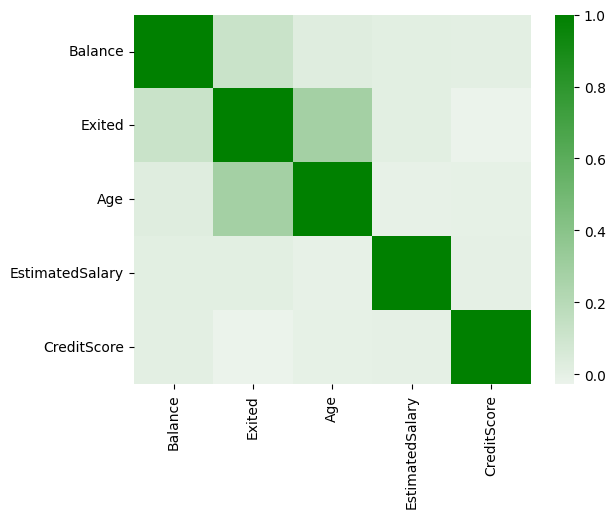

In [22]:
cmap = sns.light_palette('green',as_cmap=True)
sns.heatmap(df[num_cols].corr(),cmap=cmap)

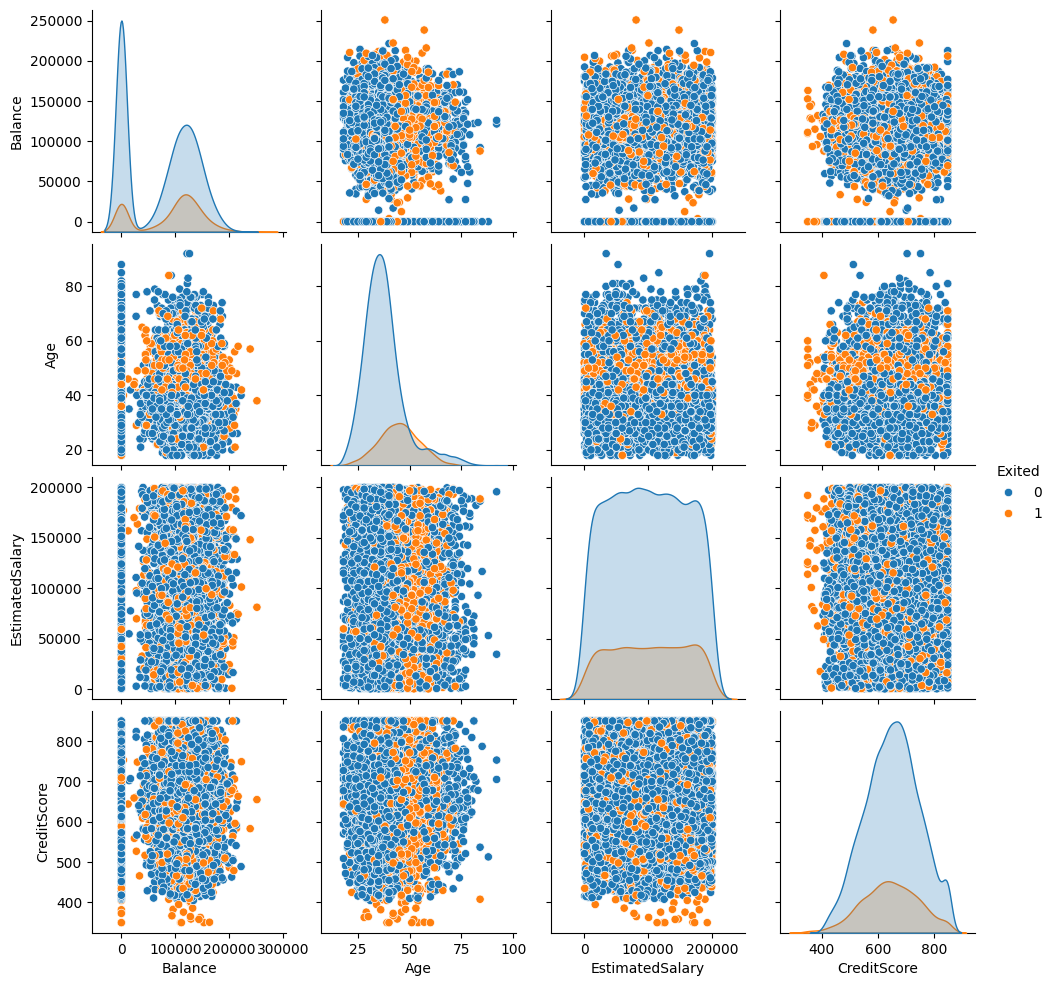

In [23]:
sns.pairplot(df[num_cols],hue='Exited')

NumOfProducts


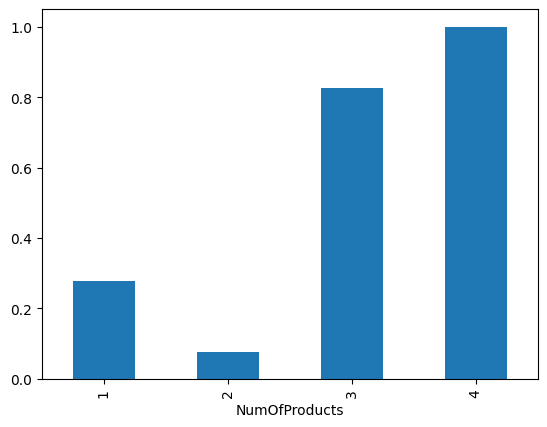

IsActiveMember


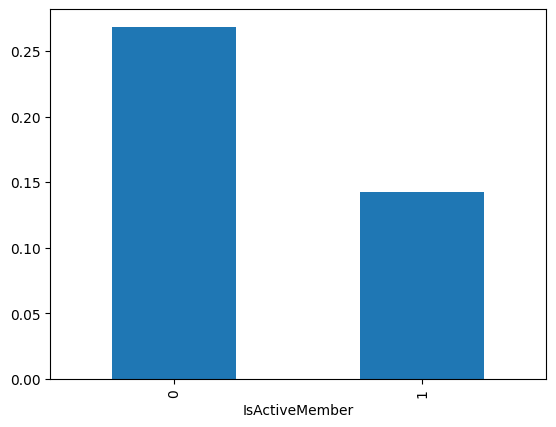

HasCrCard


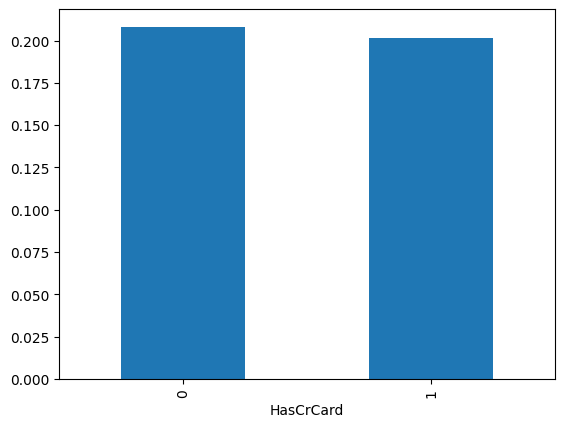

Gender


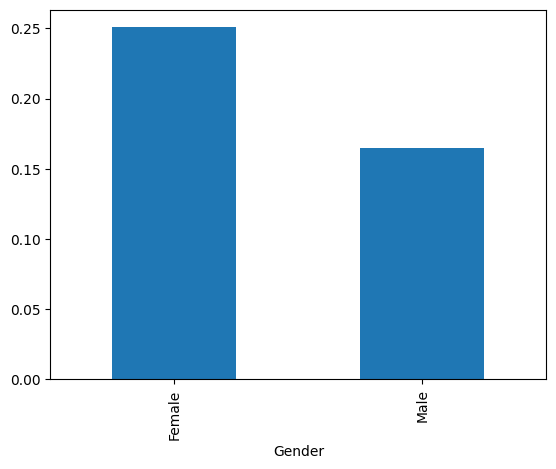

Geography


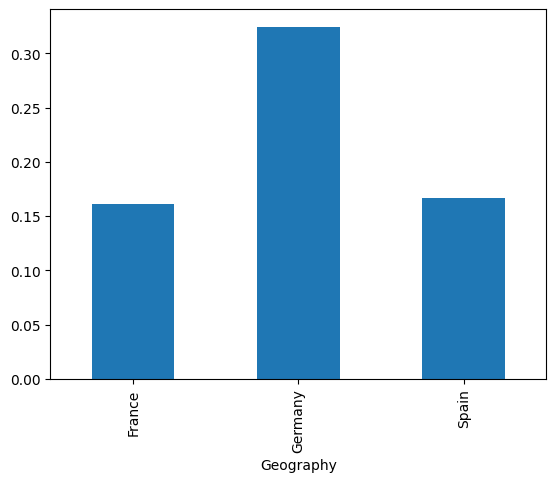

Tenure


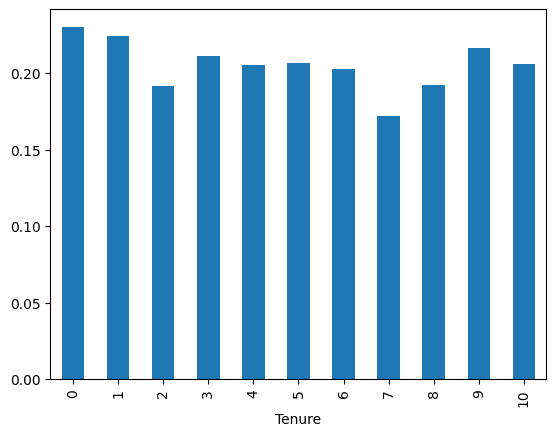

In [24]:
for i in cat_cols:
 print(i)
 df.groupby(i)['Exited'].mean().plot.bar()
 plt.show()

In [25]:
#Base Model 
#people have churn 
#anyone who has more than two products 
#anyone form germany 
#people who were not active 

df['ChurnPrediction'] = df['NumOfProducts'].apply(lambda x: 1 if x>2 else 0 )

In [26]:
print(classification_report(df['Exited'],df['ChurnPrediction']))

              precision    recall  f1-score   support

           0       0.82      0.99      0.90      7963
           1       0.86      0.14      0.24      2037

    accuracy                           0.82     10000
   macro avg       0.84      0.57      0.57     10000
weighted avg       0.83      0.82      0.76     10000



In [27]:
#predictors 
x = df[cat_cols+num_cols]
#target 
y  = df['Exited']

In [28]:
x.drop('Exited',axis=1,inplace=True)

In [29]:
print(x.shape,y.shape)

(10000, 10) (10000,)


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


In [31]:
x_train ,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

In [32]:
from sklearn.preprocessing import LabelEncoder
lb = LabelEncoder()
for i in x_train.columns:
 if x_train[i].dtype =='str':
  x_train[i] = lb.fit_transform(x_train[i])
  x_test[i] = lb.transform(x_test[i])

In [33]:
print(x_train.shape,x_test.shape,y_train.shape,y_test.shape)

(7000, 10) (3000, 10) (7000,) (3000,)


In [34]:
model = LogisticRegression()
model.fit(x_train,y_train)
pred = model.predict(x_test)
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.81      0.97      0.89      2416
           1       0.42      0.09      0.14       584

    accuracy                           0.80      3000
   macro avg       0.62      0.53      0.52      3000
weighted avg       0.74      0.80      0.74      3000



/Users/anuragpanchal/Documents/DeepLearning/DeepLearning/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [35]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(x_train,y_train)
pred2 = dt.predict(x_test)
print(classification_report(y_test,pred2))

              precision    recall  f1-score   support

           0       0.88      0.87      0.87      2416
           1       0.47      0.50      0.49       584

    accuracy                           0.79      3000
   macro avg       0.68      0.68      0.68      3000
weighted avg       0.80      0.79      0.80      3000



In [36]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [37]:
from keras.models import Sequential
from keras.layers import Dense
from keras import optimizers
from keras import metrics

In [38]:
classifier = Sequential()
classifier.add(Dense(128,activation='relu',input_dim=x_train.shape[1]))
classifier.add(Dense(64,activation='relu'))
classifier.add(Dense(32,activation='relu'))
classifier.add(Dense(16,activation='relu'))
classifier.add(Dense(1,activation='sigmoid'))
classifier.summary()

/Users/anuragpanchal/Documents/DeepLearning/DeepLearning/venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
#compile
classifier.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
#training 
history = classifier.fit(x_train,y_train,batch_size=10,epochs=10,validation_data=(x_test,y_test))

Epoch 1/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 1s 648us/step - accuracy: 0.8254 - loss: 0.4128 - val_accuracy: 0.8590 - val_loss: 0.3603
Epoch 2/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 0s 534us/step - accuracy: 0.8509 - loss: 0.3617 - val_accuracy: 0.8627 - val_loss: 0.3432
Epoch 3/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 0s 516us/step - accuracy: 0.8574 - loss: 0.3477 - val_accuracy: 0.8630 - val_loss: 0.3423
Epoch 4/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 0s 523us/step - accuracy: 0.8597 - loss: 0.3429 - val_accuracy: 0.8623 - val_loss: 0.3392
Epoch 5/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 0s 513us/step - accuracy: 0.8633 - loss: 0.3379 - val_accuracy: 0.8663 - val_loss: 0.3342
Epoch 6/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 0s 582us/step - accuracy: 0.8627 - loss: 0.3338 - val_accuracy: 0.8640 - val_loss: 0.3350
Epoch 7/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 0s 543us/step - accuracy: 0.8640 - loss: 0.3303 - val_accuracy: 0.8620 - val_loss: 0.3402
Epoch 8/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 0s 537us/step - accuracy: 0.8680 - loss: 0.3234 - 

In [40]:
y_pred = classifier.predict(x_test)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 481us/step


In [41]:
y_pred

array([[0.08812913],
       [0.02542428],
       [0.07952044],
       ...,
       [0.04156097],
       [0.01836316],
       [0.2392    ]], shape=(3000, 1), dtype=float32)

In [42]:
y_pred1 = []

for i in y_pred:
    if i>0.6:
        y_pred1.append(1)
    else:
        y_pred1.append(0)

In [43]:
y_pred1

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,


In [44]:
print(classification_report(y_test,y_pred1))

              precision    recall  f1-score   support

           0       0.88      0.97      0.92      2416
           1       0.76      0.43      0.55       584

    accuracy                           0.86      3000
   macro avg       0.82      0.70      0.74      3000
weighted avg       0.85      0.86      0.85      3000



0.8498161514560465


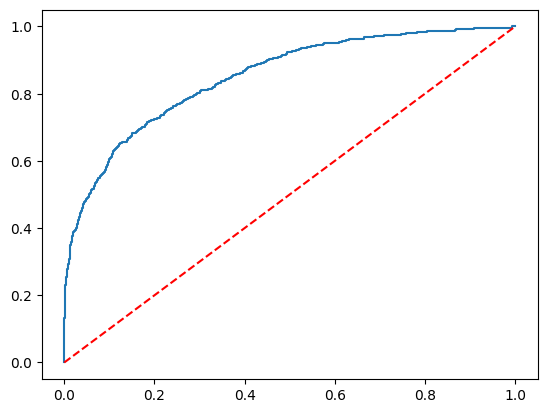

In [45]:
#roc_aoc_curve
from sklearn.metrics import roc_auc_score
fpr,tpr,thresholds= roc_curve(y_test,y_pred)
roc_auc = auc(fpr,tpr)
print(roc_auc)

#plot
plt.Figure()
plt.plot(fpr,tpr,label=f"AOC = {roc_auc}")
plt.plot([0,1],[0,1],'r--',label="ranodm gass")

In [46]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


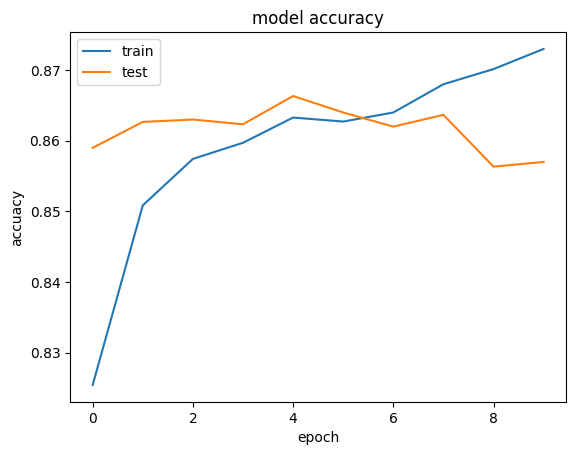

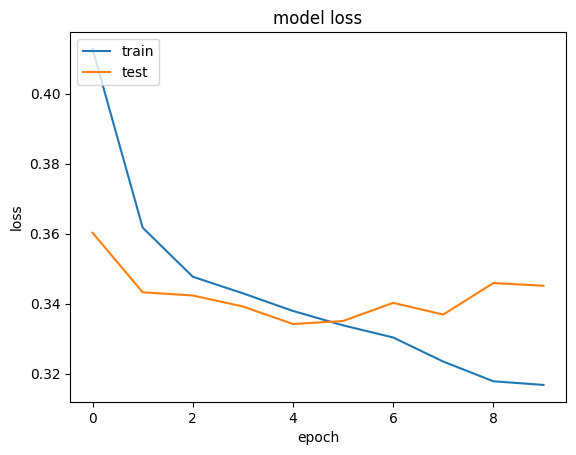

In [47]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("model accuracy")
plt.ylabel('accuacy')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='upper left')
plt.show()
#loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("model loss")
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='upper left')
plt.show()

In [49]:
#keras Functional API 
#input Layer 
input = keras.Input(shape=(10,))
#hidden layer 
hidden = Dense(5,activation='relu')(input)
#output layer 
output = Dense(1,activation='sigmoid')(hidden)
model = keras.Model(inputs=input,outputs=output,name='churn_model')
model.summary()

Model: "churn_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61 (244.00 B)

 Trainable params: 61 (244.00 B)

 Non-trainable params: 0 (0.00 B)

In [51]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
model.fit(x_train,y_train,epochs=10,validation_data=(x_test,y_test))

Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 899us/step - accuracy: 0.7924 - loss: 0.5121 - val_accuracy: 0.8053 - val_loss: 0.4762
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 542us/step - accuracy: 0.7924 - loss: 0.4788 - val_accuracy: 0.8053 - val_loss: 0.4538
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 546us/step - accuracy: 0.7924 - loss: 0.4625 - val_accuracy: 0.8053 - val_loss: 0.4423
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 542us/step - accuracy: 0.7924 - loss: 0.4532 - val_accuracy: 0.8053 - val_loss: 0.4356
Epoch 5/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 532us/step - accuracy: 0.7924 - loss: 0.4473 - val_accuracy: 0.8053 - val_loss: 0.4314
Epoch 6/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 667us/step - accuracy: 0.7924 - loss: 0.4433 - val_accuracy: 0.8053 - val_loss: 0.4276
Epoch 7/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 538us/step - accuracy: 0.8023 - loss: 0.4400 - val_accuracy: 0.8157 - val_loss: 0.4246
Epoch 8/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 534us/step - accuracy: 0.8059 - loss: 0.4375 - 